<a href="https://colab.research.google.com/github/camilaalmeiida/wine-quality-classification/blob/main/notebooks/wine_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Tech Challenge - Case Classificação de Vinhos**



## **Objetivo**

O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de
prever essa classificação a partir das variáveis disponíveis.
Sobre o dataset
Fonte: wine-quality-dataset
O conjunto de dados contém variáveis como:

Acidez fixa (fixed acidity);

Acidez volátil (volatile acidity);

Ácido cítrico (citric acid);

Açúcar residual (residual sugar);

Cloretos (chlorides);

Dióxido de enxofre livre (free sulfur dioxide);

Dióxido de enxofre total (total sulfur dioxide);

Densidade (density);

pH;

Sulfatos (sulphates);

Teor alcoólico (alcohol);

Qualidade do vinho (quality).


 **Desafio**  
Desenvolver uma pipeline de análise e modelagem, contemplando as seguintes
etapas:


## **1. Compreensão do Problema**
● Interpretar o contexto do problema.

● Definir claramente a variável alvo.

● Realizar a transformação da variável de qualidade em classificação
binária.

In [114]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [115]:
# Importar os dados da base WineQT, com delimitador do arquivo por virgula
df = pd.read_csv('WineQT.csv', sep= ",")

In [109]:
# Ler as 5 primeiras linhas da base
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [116]:
# Visualizar as ultimas 5 linhas da base
df.tail(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [117]:
# Remove a coluna Id pois não tem nenhuma utilidade para o modelo de classificação
df.drop('Id', axis=1, inplace=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [118]:
# Total de linhas e colunas
df.shape

(1143, 12)

In [119]:
# Descrição das colunas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [120]:
# Verificar se há valores nulos na base
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [121]:
# Verifica a quantidade de linhas duplicadas
df.duplicated().sum()

np.int64(125)

In [122]:
# Tipo das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [124]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [134]:
#  Transformação da variável de qualidade em classificação binária.
df["high_quality"] = 0
df.loc[df["quality"] >= 7, "high_quality"] = 1
df.head ()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


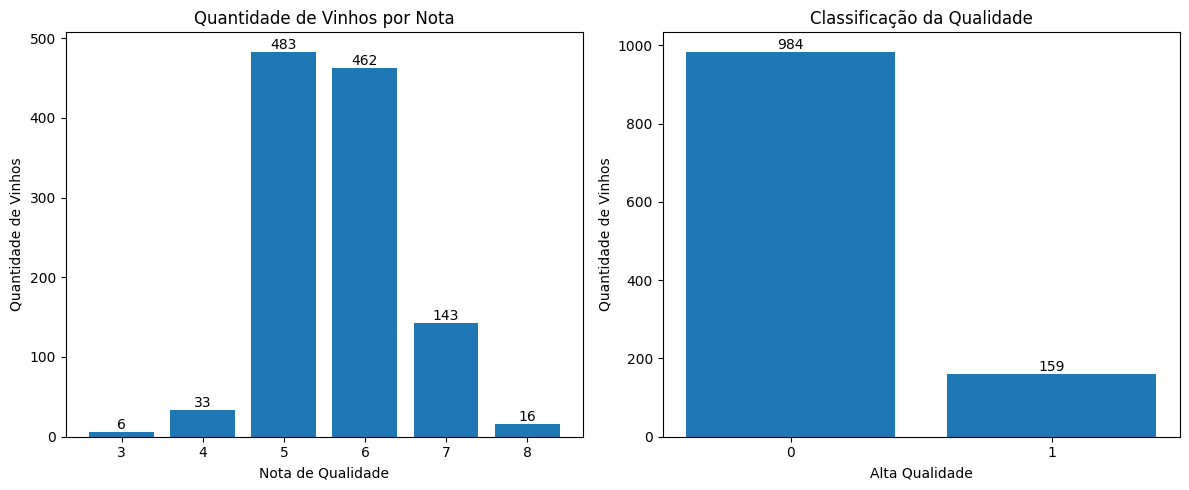

In [140]:
import matplotlib.pyplot as plt

# Contagem das notas originais
notas = df["quality"].value_counts().sort_index()

# Contagem da classificação binária
qtd_notas = df["high_quality"].value_counts().sort_index()

# Criar dois gráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ---------------- Gráfico 1 ----------------
barras1 = ax[0].bar(notas.index, notas.values)

ax[0].bar_label(barras1)
ax[0].set_xlabel("Nota de Qualidade")
ax[0].set_ylabel("Quantidade de Vinhos")
ax[0].set_title("Quantidade de Vinhos por Nota")

# ---------------- Gráfico 2 ----------------
barras2 = ax[1].bar(qtd_notas.index.astype(str), qtd_notas.values)

ax[1].bar_label(barras2)
ax[1].set_xlabel("Alta Qualidade")
ax[1].set_ylabel("Quantidade de Vinhos")
ax[1].set_title("Classificação da Qualidade")

# Ajustar espaçamento
plt.tight_layout()

# Mostrar gráficos
plt.show()

## **2. Análise Exploratória de Dados (EDA)**
● Investigar a distribuição das variáveis.

● Identificar correlações entre as variáveis e justificar cada uma delas.

● Detectar possíveis outliers ou valores inconsistentes.

● Analisar o balanceamento das classes.

In [102]:
#Descrição do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  alta_qualidade        1143 non-null   bool   
 13  1                     1143 non-null   bool   
 14  hight_quality         1143 non-null   bool   
dtypes: bool(3), float64(1

In [103]:
# Visualizar a descrição dos dados de acordo com a variavel target
df.groupby ('quality').describe()

fixed acidity                                                     \
                count      mean       std  min   25%   50%     75%   max   
quality                                                                    
3                 6.0  8.450000  2.032486  6.7  7.15  7.45   9.700  11.6   
4                33.0  7.809091  1.685668  4.6  6.70  7.60   8.500  12.5   
5               483.0  8.161077  1.557746  5.0  7.10  7.80   8.900  15.9   
6               462.0  8.317749  1.771585  5.0  7.00  7.90   9.275  14.3   
7               143.0  8.851049  2.105187  4.9  7.40  8.70  10.100  15.6   
8                16.0  8.806250  2.089168  5.0  7.35  8.85  10.400  12.6   

        volatile acidity            ... sulphates       alcohol             \
                   count      mean  ...       75%   max   count       mean   
quality                             ...                                      
3                    6.0  0.897500  ...     0.615  0.63     6.0   9.691667   
4                   33.0  0.700000  ...     0.620  2.00    33.0  10.260606   
5                  483.0  0.585280  ...     0.640  1.62   483.0   9.902277   
6                  462.0  0.504957  ...     0.740  1.95   462.0  10.655339   
7                  143.0  0.393671  ...     0.840  1.36   143.0  11.482634   
8                   16.0  0.410000  ...     0.820  1.10    16.0  11.937500   

                                                       
              std  min     25%     50%      75%   max  
quality                                                
3        0.886801  8.4   9.175   9.825  10.1375  10.9  
4        1.026200  9.0   9.400  10.000  11.0000  13.1  
5        0.752592  8.5   9.400   9.700  10.2000  14.9  
6        1.054314  8.4   9.800  10.500  11.4000  14.0  
7        0.980337  9.2  10.800  11.600  12.1000  14.0  
8        1.185397  9.8  11.225  11.750  12.8250  14.0  

[6 rows x 88 columns]

<Axes: >

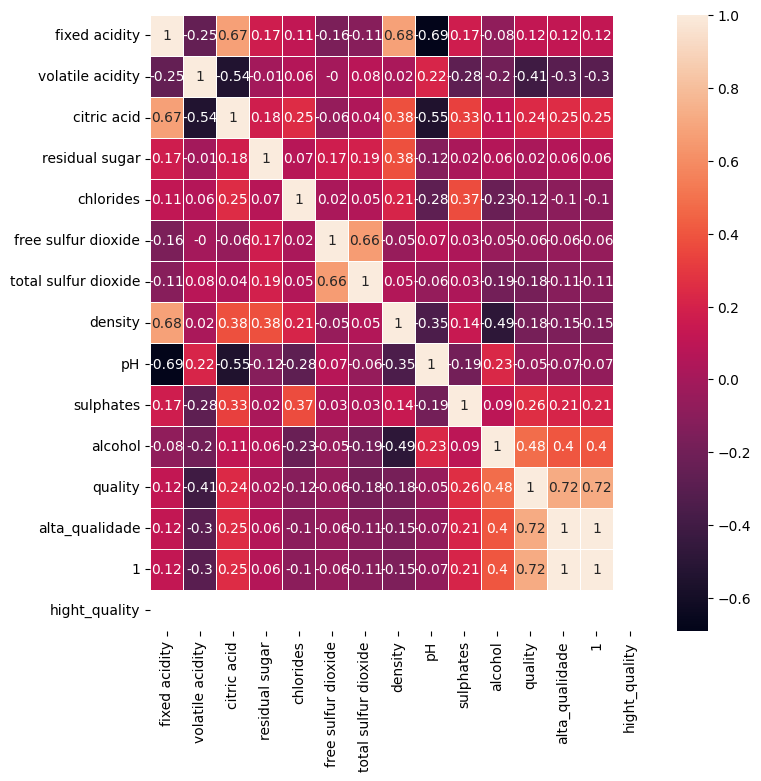

In [106]:
#analisando correlações
correlation_matrix = df.corr().round(2)

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

A análise da matriz de correlação mostrou que as relações mais fortes ocorreram entre **fixed acidity  e pH (-0,69), fixed acidity e density (0,68), acidez fixa e ácido cítrico (0,67) e dióxido de enxofre livre e total (0,66)**, todas coerentes com as propriedades físico-químicas do vinho.

Em relação à variável de interesse (quality), observou-se que o teor alcoólico apresentou a maior correlação positiva (0,48), indicando que vinhos com maior teor alcoólico tendem a ser melhor avaliados. Por outro lado, a acidez volátil apresentou a maior correlação negativa (-0,41), sugerindo que níveis elevados dessa variável estão associados à redução da qualidade do vinho. As demais variáveis apresentaram correlações fracas, indicando influência menor quando analisadas individualmente. Essas relações auxiliam na compreensão dos fatores que mais contribuem para a classificação da qualidade dos vinhos.

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com 2 linhas e 6 colunas
fig, ax = plt.subplots(2, 6, figsize=(24, 8))

# Transformar os eixos em uma lista
ax = ax.flatten()

# Lista das variáveis
colunas = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

# Criar um gráfico para cada variável
for i, coluna in enumerate(colunas):
    df.plot.scatter(
        x="quality",
        y=coluna,
        ax=ax[i],
        title=f"Qualidade x {coluna}"
    )

# Remover o último gráfico vazio
fig.delaxes(ax[11])

# Ajustar o espaçamento
plt.tight_layout()

# Exibir os gráficos
plt.show()

## **3. Pré-processamento de Dados**
● Tratamento de dados faltantes (se houver).

● Normalização ou padronização de variáveis numéricas.

● Criação de novas features (feature engineering), se considerado
relevante.

In [ ]:
from sklearn.model_selection import train_test_split

# Separar as features (X) do target (y)
X = df.drop(columns=['quality', 'Id', 'Classificacao Qualidade'])
y = df['quality']

# Separar dados para teste e para treino
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #stratify=y acredito q n precise, confirmar

In [ ]:
list(x_test)

In [ ]:
len(x_train)

In [ ]:
len(x_test)

## **4. Desenvolvimento de Modelos**
Treinar pelo menos dois modelos de classificação, e comparar o desempenho
entre eles.

## **5. Avaliação dos Modelos**
Avaliar os modelos utilizando métricas adequadas. Também deve ser realizada
uma comparação entre os modelos testados.

## **6. Interpretação dos Resultados**
● Identificar quais variáveis parecem ter maior influência na qualidade do
vinho.

● Discutir possíveis implicações para o processo de produção.
